# Wrangling and Summarizing Data

Read this notebook from top to bottom and fill in the code as you go. Work together and discuss with other students in the class. Try to resolve any errors on your own first, but don't get stuck; ask for help!

In addition to writing and running code, be sure to examine any output and interpret the results before moving on.

For many of these questions, there are several ways to do it in Pandas. You only need to choose one that works. But you might want to experiment with multiple ways of doing the same thing to get practice working with Pandas. However, you should generally try to find the simplest solution. In particular, use `groupby` whenever possible to streamline the code.

In [1]:
import pandas as pd

## Titanic data

In [2]:
df_titanic = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv")
df_titanic.head()

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN


1\. Create a new variable "type" that takes values either "passenger" or "crew".

In [3]:
def re_class_var(c):
    if c in ["1st", "2nd", "3rd"]:
        return "passenger"
    else:
        return "crew"

df_titanic["type"] = df_titanic["class"].map(re_class_var)

df_titanic.head()

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew,type
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN,passenger
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN,passenger
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN,passenger


2\. Find the proportion those onboard who were passengers and the proportion who were crew. Do this by creating a Series with these proportions.

In [4]:
df_titanic["type"].value_counts(normalize=True)

type
passenger    0.596738
crew         0.403262
Name: proportion, dtype: float64

3\. Note that "survived" is a categorical variable that has been one-hot encoded as a dummy (aka Bernoulli aka indicator) numerical variable with 1 = survived and 0 = not survived. (Check its dtype.) Find the proportion of those onboard who survived. You could do this with `value_counts` like for "type", but try a different way that takes advantage of the fact that "survived" is a numerical type. (Hint: what happens if you sum the values of a 1/0 variable? What happens if you take the mean of the values of a 1/0 variable?)

In [5]:
df_titanic["survived"].dtype

df_titanic["survived"].mean()

np.float64(0.3221567739012234)

4\. Create a crosstab (two-way table) summarizing the joint distribution of "survived" and "type". (Notice that we can treat the dummy variable "survived" as both a categorical variable and a numerical variable, whichever is convenient.)

In [6]:
pd.crosstab(df_titanic["survived"], df_titanic["type"])

type,crew,passenger
survived,,
0,679,817
1,211,500


5\. Compare the proportion of passengers who survived and the proportion of crew members who survived. Do this by creating a Series that contains these two proportions. Who was more likely to survive: passengers or crew?

Hint: there are a few ways of doing this, several of which avoid explicitly dividing. Can you take advantage of `groupby` and the fact that "survived" is a dummy variable?

In [7]:
df_titanic.groupby("type")["survived"].mean()


type
crew         0.237079
passenger    0.379651
Name: survived, dtype: float64

6\. The "gender" variable is coded only as "male" or "female". Among males only, compare the proportion of passengers who survived and the proportion of cew who survived. Among males, who was more likely to survive: passengers or crew? Then do the same thing among females only. Among females, who was more likely to survive: passengers or crew?

Do this by creating a Series that contains the 4 proportions you need. Hint: if you used `groupby` in the previous part you should only need a small change here.

In [ ]:
print(df_titanic.groupby(["gender", "type"])["survived"].mean())

gender  type     
female  crew         0.869565
        passenger    0.727468
male    crew         0.220300
        passenger    0.189189
Name: survived, dtype: float64


7\. Compare your answers to 5 and 6. What do you notice? Can you explain why this happens? Suggest an explanation and then create summaries of the data to support your explanation.

**Female passengers were much more likely to survive than male passengers overall. Also, crew members were more likely to survive than passengers. Women were boarded onto the lifeboats first, and there were many more passengers than crew members and males than females, so the proportion of passengers and males who survived would likely be generally less than the proportion of crewmembers and females. Additionally, most crewmembers were likely males.**

In [9]:
df_titanic.groupby(["gender"])["survived"].mean()

gender
female    0.734151
male      0.204889
Name: survived, dtype: float64

In [10]:
print(df_titanic.groupby(["gender"])["type"].value_counts(normalize=True))

gender  type     
female  passenger    0.952965
        crew         0.047035
male    crew         0.504657
        passenger    0.495343
Name: proportion, dtype: float64


## College Scorecard

The [College Scorecard](https://collegescorecard.ed.gov/) was an effort started by the U.S. Department of Education to help students make more informed choices about colleges. Data from 2022 is available at https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv


In [11]:
df_college = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv")

df_college

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0
6541,Pennsylvania State University-Penn State Brand...,Media,PA,NaN,61185.0


1\. What is the observational unit? Make a guess for how the earnings variable is computed.

**Institution is the observational unit, and median earnings is maybe found by taking the median value of earnings from university graduates**

2\. Write code to find the California Polytechnic row in the data set!

In [12]:
df_college[df_college["Institution"].str.contains("California Poly")]

,Institution,City,State,Undergraduates,Median Earnings
194,California Polytechnic State University-San Lu...,San Luis Obispo,CA,21090.0,85801.0


3\. The data set contains information about the median earnings of students who attended each college, 10 years after they first enrolled. The earnings are taken directly from the W2 tax forms of all students who received federal financial aid.

Notice the earnings are missing (NaN). Create a subset data frame that only includes colleges with non-missing earnings. Use this subset to answer the remaining questions.

In [13]:
df_college_clean = df_college.dropna(subset=["Median Earnings"]).copy()
df_college_clean


,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6537,Pennsylvania State University-Penn State Wilke...,Lehman,PA,NaN,61185.0
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0


4\. Summarize the earnings variable, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command! What is larger: the mean or the median? Why? Then create a histogram of the earnings variable.

**The mean is larger because it is being skewed by extremely large salaries**

In [14]:
df_college_clean["Median Earnings"].describe()


count      5165.000000
mean      41128.801355
std       16185.531482
min       11085.000000
25%       29448.000000
50%       38696.000000
75%       49077.000000
max      129442.000000
Name: Median Earnings, dtype: float64

<Axes: ylabel='Frequency'>

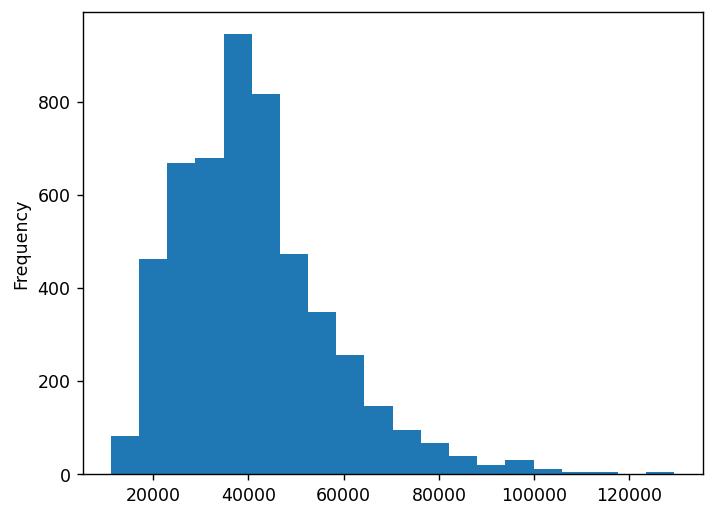

In [15]:
df_college_clean["Median Earnings"].plot.hist(bins=20)



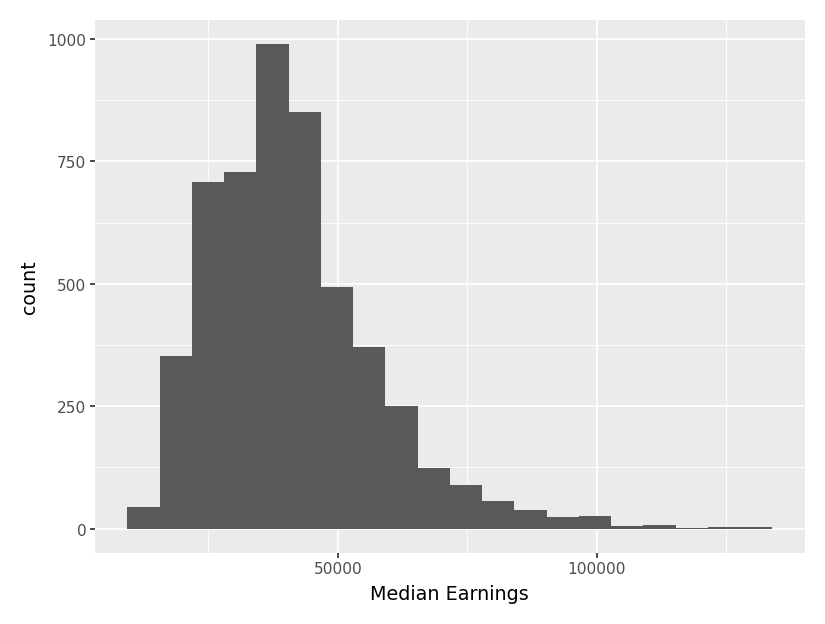

In [16]:
from plotnine import *
(ggplot(df_college_clean, aes(x="Median Earnings"))
 + geom_histogram(bins=20)
)

5\. Create a new column with the log of earnings, then create a histogram. How does the shape of the histogram of log earnings compare to earnings itself?

<Axes: ylabel='Frequency'>

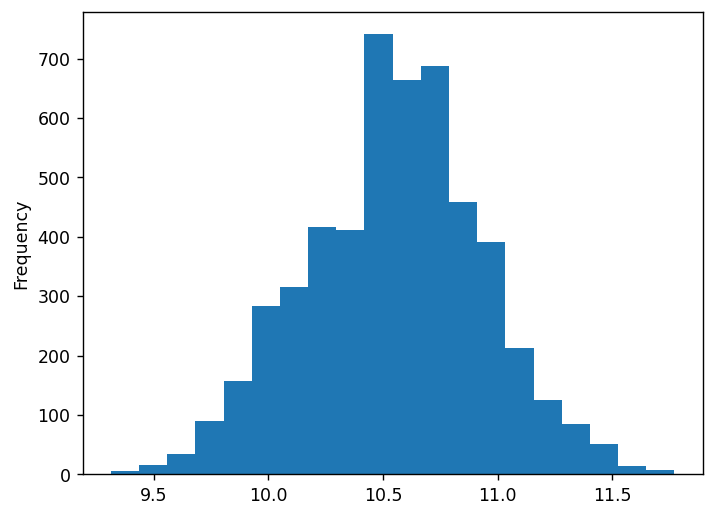

In [17]:
import numpy as np

df_college_clean["Log Earnings"] = np.log(df_college_clean["Median Earnings"])
df_college_clean["Log Earnings"].plot.hist(bins=20)


6\. The mean gives every college equal weight. But some colleges are tiny (e.g., San Francisco Conservatory, with 228 undergraduates), while others are large (e.g., Penn State, with 72229 undergraduates!).

If we are interested in what *students* earn, we might want to give more weight to colleges with more students. To do this, we can calculate a **weighted mean**:

$$ \sum_{i=1}^n w_i x_i. $$

In general, the weights $w_1, w_2, ..., w_n$ should all be non-negative and should add up to $1.0$. (For the usual mean, every observation gets equal weight, $1/n$.)

Calculate a weighted mean of earnings, using the undergraduate enrollments as weights. Do this by first adding a "weight" column to the data set (number of undegraduates for the college divided by the total number of undergraduates in the data set).

In [18]:
total_undergrad = df_college_clean["Undergraduates"].sum()
df_college_clean["weight"] = df_college_clean["Undergraduates"] / total_undergrad

weighted_mean_earnings = (df_college_clean["weight"] * df_college_clean["Median Earnings"]).sum()
weighted_mean_earnings


np.float64(50608.33831282287)

7\. Compute the mean of earnings for each state. Sort the states in descending order of mean earnings. Display the results in a bar chart.

State
MA    56633.768519
VT    53040.230769
RI    52605.947368
DC    51325.470588
CT    50771.413793
NH    49322.333333
NY    48752.694352
WA    47733.266667
PA    47607.290210
MN    45855.938776
NJ    44964.081081
CA    44461.812371
MD    44454.342857
NE    43776.868421
AK    43604.500000
WI    43417.909091
ME    43400.032258
IN    43311.268519
IL    42443.338624
HI    42162.437500
OR    41934.816667
IA    41809.521127
VA    41803.976744
MO    41702.425197
CO    41578.523077
KS    41244.690141
NV    41184.741935
SD    41136.608696
AZ    40854.298851
DE    40319.153846
OH    40115.951613
ND    39603.080000
VI    39307.000000
WY    38966.300000
GA    38845.460526
AL    38225.338028
TX    38074.490683
MI    37855.232394
MT    37653.480000
NC    37178.948387
NM    36994.588235
TN    36866.411290
SC    36446.682927
FL    36162.099668
UT    35862.604651
WV    35782.507937
OK    35564.678161
KY    35171.828571
MH    34483.000000
LA    34087.642857
AR    32972.202703
ID    32823.666667
MS    

<Axes: title={'center': 'Mean Earnings by State'}, xlabel='State', ylabel='Mean Median Earnings'>

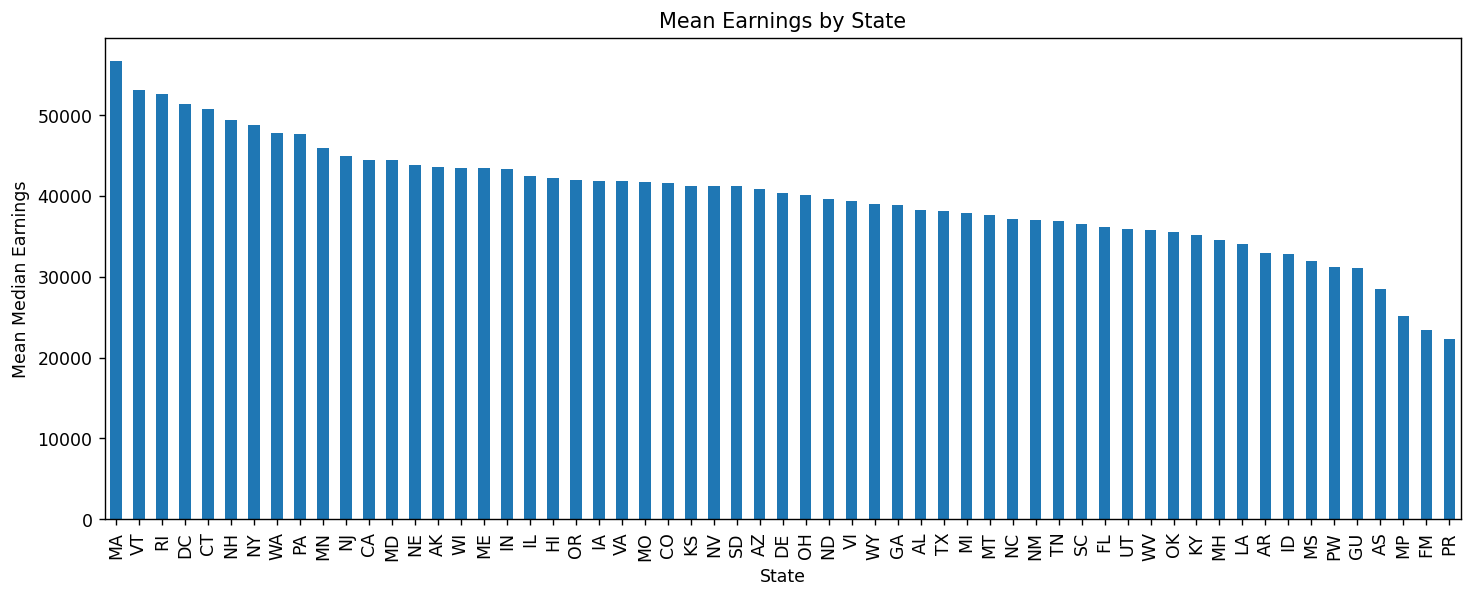

In [ ]:
state_mean_earnings = (
    df_college_clean.groupby("State")["Median Earnings"]
    .mean().sort_values(ascending=False)
)

print(state_mean_earnings)
state_mean_earnings.plot.bar(figsize=(14, 5), ylabel="Mean Median Earnings", title="Mean Earnings by State")


8\. Repeat the previous part, but now compute a weighted mean of earnings for each state, using the number of undegraduate enrollments in the state as weights. (Hint: use `groupby` with `transform`.)

State
DC    69939.367698
MA    65365.038613
RI    61382.901051
VT    58815.822129
CT    58515.071887
PA    58152.366783
NY    57869.188381
DE    56136.291687
MD    56049.152616
WA    55332.820949
NH    55043.032070
NJ    54956.421801
UT    54274.369021
ND    53733.319895
VA    53265.020364
MN    53257.575881
WI    52622.024037
IL    52567.618773
CA    51861.217937
IA    51723.723529
NE    51268.810074
CO    50724.480712
OR    50632.035920
IN    50227.922229
MI    50057.879324
WV    50012.392262
MO    49111.791894
TX    48719.078342
ID    48550.410338
HI    48235.746445
AK    47484.939237
SD    47463.984742
GA    47246.144980
KS    47195.607294
ME    47025.392744
NV    46974.859922
FL    46868.957171
OH    46457.828084
SC    46361.251566
AZ    46269.729336
MT    46245.688158
AL    46235.575067
WY    45676.820836
NC    45554.928093
OK    45200.927650
TN    44455.268088
LA    43624.414206
KY    42942.305706
AR    42616.774237
VI    39307.000000
MS    38593.953921
NM    38089.932224
MH    

<Axes: title={'center': 'Enrollment-Weighted Mean Earnings by State'}, xlabel='State', ylabel='Weighted Mean Median Earnings'>

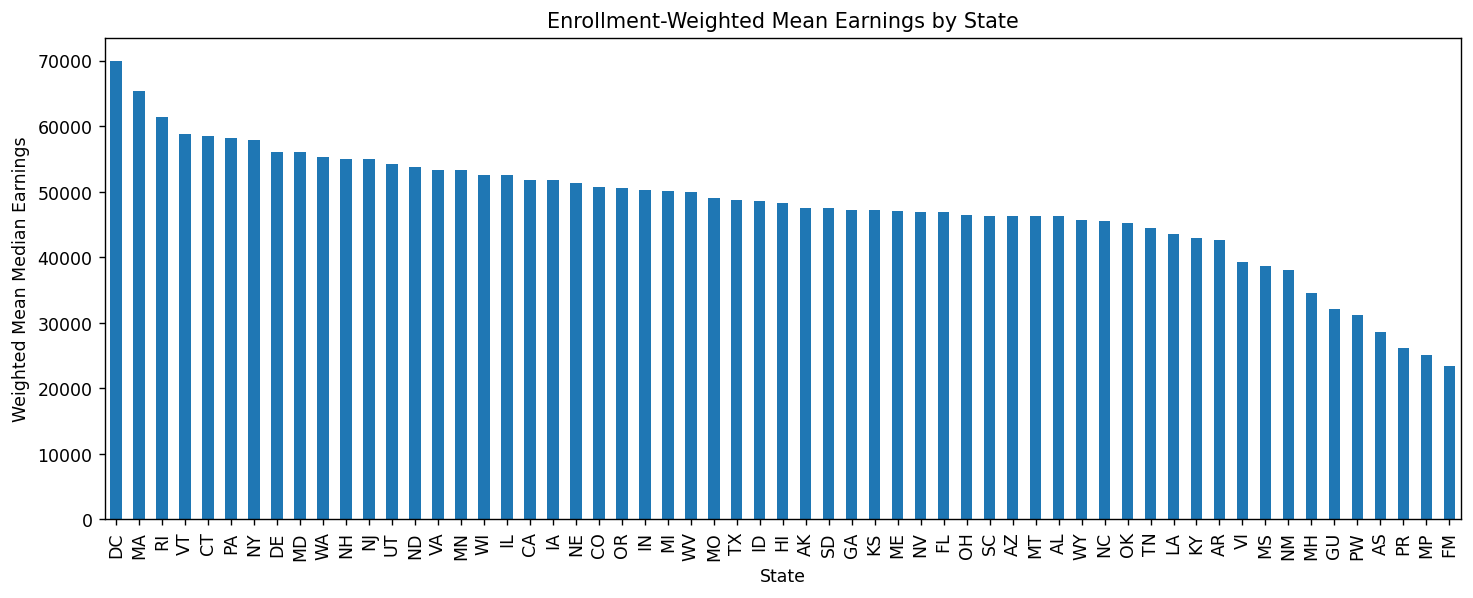

In [20]:
state_total_undergrad = df_college_clean.groupby("State")["Undergraduates"].transform("sum")
df_college_clean["state_weight"] = df_college_clean["Undergraduates"] / state_total_undergrad
df_college_clean["weighted_earnings"] = df_college_clean["state_weight"] * df_college_clean["Median Earnings"]

state_weighted_mean_earnings = (
    df_college_clean.groupby("State")["weighted_earnings"]
    .sum()
    .sort_values(ascending=False)
)

print(state_weighted_mean_earnings)
state_weighted_mean_earnings.plot.bar(figsize=(14, 5), ylabel="Weighted Mean Median Earnings", title="Enrollment-Weighted Mean Earnings by State")


## Olympic Men's Gymnastics Data



The file https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

In [21]:
df_gym = pd.read_csv("https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv")

df_gym

,Pos,Gymnast,NOC,Points,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Round,Year
0,1.0,Danell Leyva,USA,91.265,15.100,15.500,15.333,15.866,14.600,14.866,Qualification,2012
1,2.0,David Belyavsky,RUS,90.832,15.100,16.300,15.300,14.866,14.366,14.900,Qualification,2012
2,3.0,Fabian HambÃ¼chen,GER,90.765,15.133,15.833,15.300,15.633,14.766,14.100,Qualification,2012
3,4.0,John Orozco,USA,90.597,15.166,15.800,14.533,15.266,15.066,14.766,Qualification,2012
4,5.0,Kristian Thomas,GBR,90.256,15.366,16.200,14.625,15.366,14.566,14.133,Qualification,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
346,20.0,Daniel Keatings,GBR,89.000,14.850,15.800,14.425,14.225,14.000,15.700,Final,2008
347,21.0,Thomas Bouhail,FRA,87.000,15.200,15.850,14.425,14.475,13.650,13.400,Final,2008
348,22.0,José Luis Fuentes,VEN,86.300,14.175,15.250,15.175,14.150,13.900,13.650,Final,2008
349,23.0,Dzmitry Savitski,BLR,82.175,13.725,15.900,13.400,10.100,15.300,13.750,Final,2008


1\. Create a data frame

- With [Round, Year, Gymnast] as the (multi) index, and
- Containing only the six columns with the event scores, "Floor Exercise" through "Pommelled Horse"

In [ ]:
event_cols = ["Floor Exercise", "Horse Vault", "Parallel Bars", "Horizontal Bar", "Rings", "Pommelled Horse"]

df_gym_events = (
    df_gym.set_index(["Round", "Year", "Gymnast"])[event_cols].copy()
)

df_gym_events


Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva               15.100       15.500   
                   David Belyavsky            15.100       16.300   
                   Fabian HambÃ¼chen          15.133       15.833   
                   John Orozco                15.166       15.800   
                   Kristian Thomas            15.366       16.200   
...                                              ...          ...   
Final         2008 Daniel Keatings            14.850       15.800   
                   Thomas Bouhail             15.200       15.850   
                   José Luis Fuentes          14.175       15.250   
                   Dzmitry Savitski           13.725       15.900   
                   Chen Yibing                   NaN       15.900   

                                      Parallel Bars  Horizontal Bar   Rings  \
Round         Year Gymnast                                                    
Qualification 2012 Danell Leyva              15.333          15.866  14.600   
                   David Belyavsky           15.300          14.866  14.366   
                   Fabian HambÃ¼chen         15.300          15.633  14.766   
                   John Orozco               14.533          15.266  15.066   
                   Kristian Thomas           14.625          15.366  14.566   
...                                             ...             ...     ...   
Final         2008 Daniel Keatings           14.425          14.225  14.000   
                   Thomas Bouhail            14.425          14.475  13.650   
                   José Luis Fuentes         15.175          14.150  13.900   
                   Dzmitry Savitski          13.400          10.100  15.300   
                   Chen Yibing               14.950          12.975  16.650   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva                14.866  
                   David Belyavsky             14.900  
                   Fabian HambÃ¼chen           14.100  
                   John Orozco                 14.766  
                   Kristian Thomas             14.133  
...                                               ...  
Final         2008 Daniel Keatings             15.700  
                   Thomas Bouhail              13.400  
                   José Luis Fuentes           13.650  
                   Dzmitry Savitski            13.750  
                   Chen Yibing                 13.750  

[351 rows x 6 columns]

2\. Summarize the scores for each of the six events, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command!

In [23]:
df_gym_events.describe()


,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,324.000000,318.000000,325.000000
mean,14.309133,14.976551,14.719288,14.082562,14.237799,13.816723
std,1.254009,0.959876,0.920044,1.299542,0.914523,1.242348
min,1.633000,11.766000,10.200000,0.000000,7.700000,0.000000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.854000,14.831000,14.566000
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


3\. There are 351 rows in the data frame. Why are the sample sizes different for each event, and not all equal to 351?

**The sample sizes differ because some gymnasts did not compete in every event, so their scores are missing. Pandas `describe()` counts only non-missing values for each event, which means the event-specific counts do not all have to equal the 351 rows in the data set.**


4\. In the all around competition, each gymnast competes all six events, but this doesn't always happen (due to injury, etc). Therefore, there are some missing values in the data. Most of the missing values are coded as `NaN` but some are coded as 0. What would be a more appropriate way to code the missing values in this case: `NaN` or 0? Why?

**`NaN` is more appropriate. A missing score means the gymnast did not compete in that event, whereas a score of 0 would be treated as an actual performance score. Leaving missing events as 0 would incorrectly pull means downward and distort standard deviations, correlations, and standardized scores.**


5\. Replace all scores of 0 in the data frame with `NaN`. (Note: It is possible to actually score a 0 on some events, e.g., if you do a vault but don't land feet first. But the few 0s in this data set are for people who didn't compete the event at all.)

In [24]:
df_gym_events = df_gym_events.replace(0, np.nan)
df_gym_events


Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva               15.100       15.500   
                   David Belyavsky            15.100       16.300   
                   Fabian HambÃ¼chen          15.133       15.833   
                   John Orozco                15.166       15.800   
                   Kristian Thomas            15.366       16.200   
...                                              ...          ...   
Final         2008 Daniel Keatings            14.850       15.800   
                   Thomas Bouhail             15.200       15.850   
                   José Luis Fuentes          14.175       15.250   
                   Dzmitry Savitski           13.725       15.900   
                   Chen Yibing                   NaN       15.900   

                                      Parallel Bars  Horizontal Bar   Rings  \
Round         Year Gymnast                                                    
Qualification 2012 Danell Leyva              15.333          15.866  14.600   
                   David Belyavsky           15.300          14.866  14.366   
                   Fabian HambÃ¼chen         15.300          15.633  14.766   
                   John Orozco               14.533          15.266  15.066   
                   Kristian Thomas           14.625          15.366  14.566   
...                                             ...             ...     ...   
Final         2008 Daniel Keatings           14.425          14.225  14.000   
                   Thomas Bouhail            14.425          14.475  13.650   
                   José Luis Fuentes         15.175          14.150  13.900   
                   Dzmitry Savitski          13.400          10.100  15.300   
                   Chen Yibing               14.950          12.975  16.650   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva                14.866  
                   David Belyavsky             14.900  
                   Fabian HambÃ¼chen           14.100  
                   John Orozco                 14.766  
                   Kristian Thomas             14.133  
...                                               ...  
Final         2008 Daniel Keatings             15.700  
                   Thomas Bouhail              13.400  
                   José Luis Fuentes           13.650  
                   Dzmitry Savitski            13.750  
                   Chen Yibing                 13.750  

[351 rows x 6 columns]

6\. Summarize the revised data. Which events tend to have the highest scores? The lowest? Which events have the greatest degree of variability in scores? The least?

In [25]:
gym_summary = df_gym_events.describe()
print(gym_summary)

print(df_gym_events.mean().sort_values(ascending=False))

print(df_gym_events.std().sort_values(ascending=False))


       Floor Exercise  Horse Vault  Parallel Bars  Horizontal Bar       Rings  \
count      324.000000   323.000000     323.000000      323.000000  318.000000   
mean        14.309133    14.976551      14.719288       14.126161   14.237799   
std          1.254009     0.959876       0.920044        1.037426    0.914523   
min          1.633000    11.766000      10.200000        9.433000    7.700000   
25%         13.866000    14.300000      14.233000       13.475000   13.700000   
50%         14.500000    15.058000      14.900000       14.300000   14.275000   
75%         15.033000    15.700000      15.350000       14.858000   14.831000   
max         15.950000    16.775000      16.425000       16.200000   16.650000   

       Pommelled Horse  
count       324.000000  
mean         13.859367  
std           0.977423  
min          10.666000  
25%          13.266000  
50%          13.925000  
75%          14.574500  
max          16.000000  
Horse Vault        14.976551
Parallel Bars   

7\. Compute the correlation matrix. For which pairs of events is the correlation the highest? The lowest?

In [26]:
corr_matrix = df_gym_events.corr()
print(corr_matrix)

# Pull out each event pair once (upper triangle only).
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = upper_triangle.stack().sort_values(ascending=False)

print(corr_pairs.head(1))
print(corr_pairs.tail(1))


                 Floor Exercise  Horse Vault  Parallel Bars  Horizontal Bar  \
Floor Exercise         1.000000     0.440092       0.351537        0.378685   
Horse Vault            0.440092     1.000000       0.383301        0.500211   
Parallel Bars          0.351537     0.383301       1.000000        0.557611   
Horizontal Bar         0.378685     0.500211       0.557611        1.000000   
Rings                  0.494417     0.595005       0.589963        0.491114   
Pommelled Horse        0.289385     0.367616       0.481337        0.449014   

                    Rings  Pommelled Horse  
Floor Exercise   0.494417         0.289385  
Horse Vault      0.595005         0.367616  
Parallel Bars    0.589963         0.481337  
Horizontal Bar   0.491114         0.449014  
Rings            1.000000         0.420985  
Pommelled Horse  0.420985         1.000000  
Horse Vault  Rings    0.595005
dtype: float64
Floor Exercise  Pommelled Horse    0.289385
dtype: float64


8\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.

In [27]:
df_gym_std = (df_gym_events - df_gym_events.mean()) / df_gym_events.std()
df_gym_std


Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             0.630671     0.545330   
                   David Belyavsky          0.630671     1.378771   
                   Fabian HambÃ¼chen        0.656987     0.892250   
                   John Orozco              0.683303     0.857870   
                   Kristian Thomas          0.842791     1.274591   
...                                              ...          ...   
Final         2008 Daniel Keatings          0.431311     0.857870   
                   Thomas Bouhail           0.710416     0.909960   
                   José Luis Fuentes       -0.106963     0.284879   
                   Dzmitry Savitski        -0.465812     0.962050   
                   Chen Yibing                   NaN     0.962050   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            0.667047        1.677073  0.396055   
                   David Belyavsky         0.631179        0.713149  0.140184   
                   Fabian HambÃ¼chen       0.631179        1.452479  0.577570   
                   John Orozco            -0.202477        1.098718  0.905610   
                   Kristian Thomas        -0.102482        1.195111  0.358877   
...                                             ...             ...       ...   
Final         2008 Daniel Keatings        -0.319863        0.095273 -0.260025   
                   Thomas Bouhail         -0.319863        0.336254 -0.642738   
                   José Luis Fuentes       0.495316        0.022979 -0.369372   
                   Dzmitry Savitski       -1.433940       -3.880914  1.161481   
                   Chen Yibing             0.250762       -1.109632  2.637661   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              1.029884  
                   David Belyavsky           1.064669  
                   Fabian HambÃ¼chen         0.246191  
                   John Orozco               0.927574  
                   Kristian Thomas           0.279953  
...                                               ...  
Final         2008 Daniel Keatings           1.883148  
                   Thomas Bouhail           -0.469978  
                   José Luis Fuentes        -0.214203  
                   Dzmitry Savitski         -0.111893  
                   Chen Yibing              -0.111893  

[351 rows x 6 columns]

9\. The all around champion is whoever has the highest total score for the six events (in the finals). But who is the "all around standardized value champion"? Create a column that sums the standardized values for each athlete, then sort the data frame in descending order by that column. Note: you should NOT have to manually add six columns.

In [28]:
df_gym_std_with_total = df_gym_std.copy()
df_gym_std_with_total["Total Standardized Value"] = df_gym_std.sum(axis=1, min_count=6)

df_gym_std_with_total.sort_values("Total Standardized Value", ascending=False).head(10)


Floor Exercise  Horse Vault  \
Round         Year Gymnast                                         
Final         2008 Yang Wei                0.750288     1.639221   
Qualification 2008 Yang Wei                0.869904     1.639221   
Final         2012 Kohei Uchimura          0.630671     1.343350   
Qualification 2008 Kim Dae-Eun             0.949648     1.118320   
Final         2016 Oleh Verniaiev          0.577243     0.545330   
Qualification 2008 Fabian Hambüchen        1.188881     1.378771   
Final         2016 Kohei Uchimura          1.161768     0.614089   
Qualification 2016 Oleh Verniaiev          0.417754     0.093188   
              2008 Koki Sakamoto           0.511055     1.274591   
                   Kohei Uchimura          1.129073     1.274591   

                                     Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                     
Final         2008 Yang Wei               1.500703        0.625432  2.610324   
Qualification 2008 Yang Wei               0.685524        0.770020  2.172938   
Final         2012 Kohei Uchimura         0.658351        1.420669  1.197566   
Qualification 2008 Kim Dae-Eun            1.446357        0.480843  1.325501   
Final         2016 Oleh Verniaiev         1.500703        0.649530  1.161481   
Qualification 2008 Fabian Hambüchen       1.446357        1.999024  0.806105   
Final         2016 Kohei Uchimura         0.957250        1.613454  0.541486   
Qualification 2016 Oleh Verniaiev         1.572438        0.970517  1.052135   
              2008 Koki Sakamoto          0.984423        0.577235  1.407511   
                   Kohei Uchimura         1.419185        1.155590  0.478065   

                                     Pommelled Horse  Total Standardized Value  
Round         Year Gymnast                                                      
Final         2008 Yang Wei                 1.448331                  8.574298  
Qualification 2008 Yang Wei                 1.601796                  7.739403  
Final         2012 Kohei Uchimura           1.234504                  6.485111  
Qualification 2008 Kim Dae-Eun              0.885627                  6.206298  
Final         2016 Oleh Verniaiev           1.712291                  6.146577  
Qualification 2008 Fabian Hambüchen        -0.776907                  6.042231  
Final         2016 Kohei Uchimura           1.064669                  5.952716  
Qualification 2016 Oleh Verniaiev           1.746053                  5.852085  
              2008 Koki Sakamoto            1.090247                  5.845062  
                   Kohei Uchimura           0.246191                  5.702694

10\. Compute the mean score for each event in each year. How do the means change over time? Why do you think this happened?

**The event means generally shift downward from 2008 to the later Olympics, although the exact pattern varies by event. A likely reason is that the gymnastics Code of Points and judging standards changed across Olympic cycles, so raw scores from different years are not perfectly comparable.**


      Floor Exercise  Horse Vault  Parallel Bars  Horizontal Bar      Rings  \
Year                                                                          
2008       14.720250    15.841753      15.125758       14.563750  14.850532   
2012       14.495154    15.484308      14.663231       14.365922  14.441462   
2016       14.134667    14.496068      14.787083       14.246315  14.201514   
2020       13.841989    14.046398      14.242529       13.336919  13.453632   

      Pommelled Horse  
Year                   
2008        14.248750  
2012        13.787172  
2016        14.051319  
2020        13.312341  


<Axes: title={'center': 'Mean Gymnastics Event Scores by Olympic Year'}, ylabel='Mean Score'>

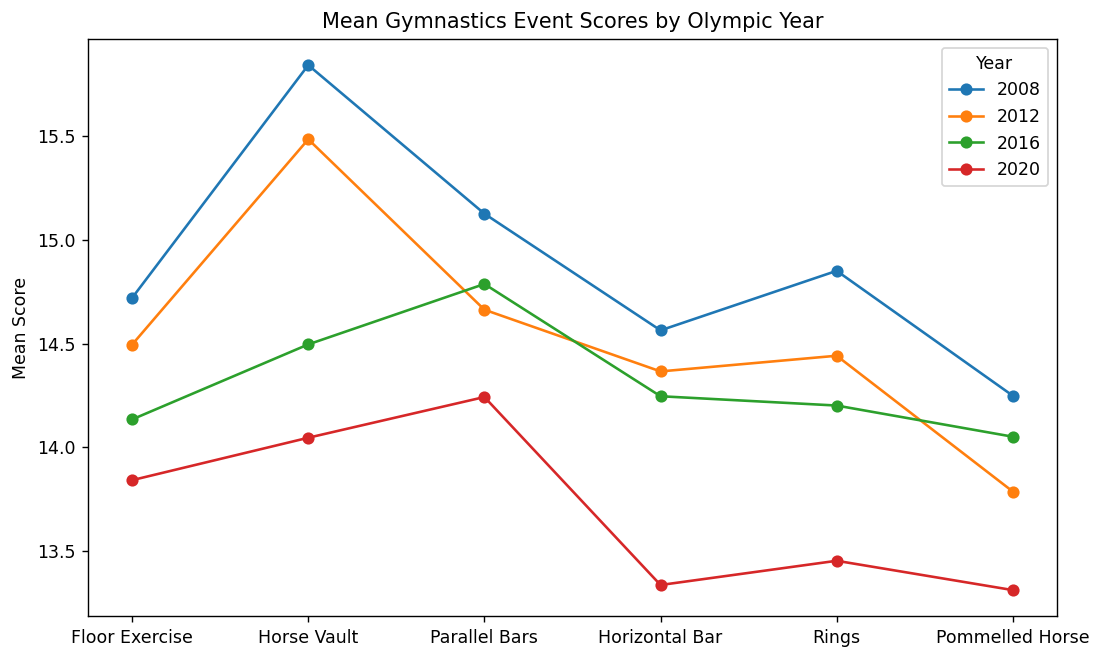

In [29]:
year_event_means = df_gym_events.groupby(level="Year").mean()
print(year_event_means)

(
    year_event_means.T
    .plot(figsize=(10, 6), marker="o", ylabel="Mean Score", title="Mean Gymnastics Event Scores by Olympic Year")
)


11\. Choose one event and for that event create a plot with a single panel that summarizes the distribution of scores for each of the four years. Describe what you see.

**I chose Floor Exercise. The boxplots make it easy to compare the center, spread, and unusual scores across the four Olympic years. The 2008 scores are generally shifted higher than the later years, while the later distributions occur at lower score levels. This is consistent with changes in scoring standards over time.**


C:\Users\jaxle\anaconda3\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_boxplot : Removed 27 rows containing non-finite values.


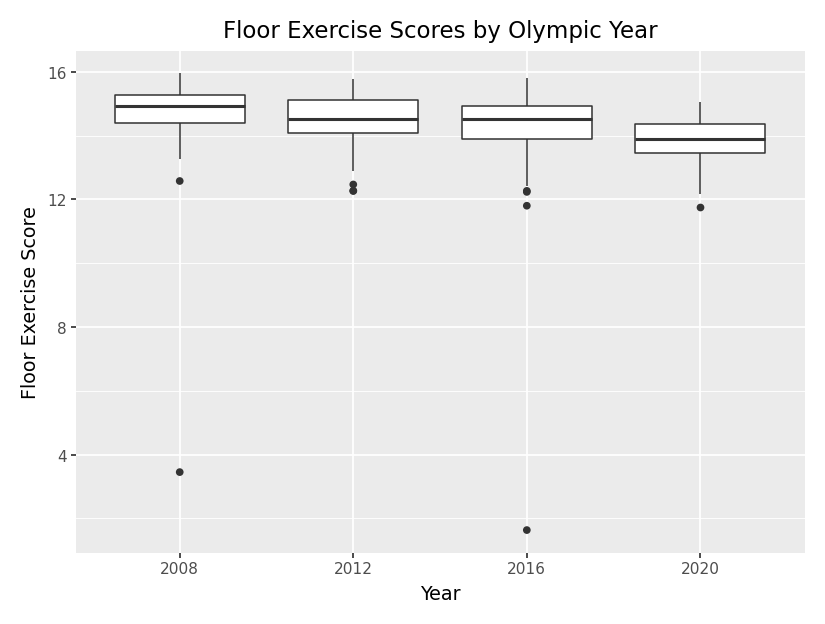

In [30]:
floor_by_year = df_gym_events.reset_index()
floor_by_year["Year"] = floor_by_year["Year"].astype(str)

(ggplot(floor_by_year, aes(x="Year", y="Floor Exercise"))
 + geom_boxplot()
 + labs(x="Year", y="Floor Exercise Score", title="Floor Exercise Scores by Olympic Year")
)


12\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation *within each year*. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.


In [31]:
year_means = df_gym_events.groupby(level="Year").transform("mean")
year_sds = df_gym_events.groupby(level="Year").transform("std")

df_gym_std_by_year = (df_gym_events - year_means) / year_sds
df_gym_std_by_year


Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             0.753096     0.027915   
                   David Belyavsky          0.753096     1.451057   
                   Fabian HambÃ¼chen        0.794185     0.620298   
                   John Orozco              0.835273     0.561594   
                   Kristian Thomas          1.084294     1.273164   
...                                              ...          ...   
Final         2008 Daniel Keatings          0.098864    -0.076907   
                   Thomas Bouhail           0.365547     0.015192   
                   José Luis Fuentes       -0.415455    -1.089993   
                   Dzmitry Savitski        -0.758335     0.107290   
                   Chen Yibing                   NaN     0.107290   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            1.002995        1.708332  0.269011   
                   David Belyavsky         0.953577        0.569503 -0.128045   
                   Fabian HambÃ¼chen       0.953577        1.442985  0.550683   
                   John Orozco            -0.195024        1.025035  1.059729   
                   Kristian Thomas        -0.057251        1.138917  0.211319   
...                                             ...             ...       ...   
Final         2008 Daniel Keatings        -0.896615       -0.385333 -1.098537   
                   Thomas Bouhail         -0.896615       -0.100954 -1.550593   
                   José Luis Fuentes       0.063005       -0.470647 -1.227696   
                   Dzmitry Savitski       -2.208096       -5.077583  0.580528   
                   Chen Yibing            -0.224881       -1.807227  2.324171   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              1.232874  
                   David Belyavsky           1.271729  
                   Fabian HambÃ¼chen         0.357497  
                   John Orozco               1.118595  
                   Kristian Thomas           0.395209  
...                                               ...  
Final         2008 Daniel Keatings           1.745577  
                   Thomas Bouhail           -1.020884  
                   José Luis Fuentes        -0.720182  
                   Dzmitry Savitski         -0.599901  
                   Chen Yibing              -0.599901  

[351 rows x 6 columns]

13\. If we standardize within each year, which athletes (and rounds and year) had the highest total standardized values? Basically repeat part 9 but with standardization within each year.

In [32]:
df_gym_std_by_year_with_total = df_gym_std_by_year.copy()
df_gym_std_by_year_with_total["Total Standardized Value"] = df_gym_std_by_year.sum(axis=1, min_count=6)

df_gym_std_by_year_with_total.sort_values("Total Standardized Value", ascending=False).head(10)


Floor Exercise  Horse Vault  \
Round         Year Gymnast                                        
Final         2016 Oleh Verniaiev         0.520383     1.475149   
              2012 Kohei Uchimura         0.753096     1.390574   
Qualification 2020 Daiki Hashimoto        1.196662     1.341947   
Final         2020 Daiki Hashimoto        1.382156     1.070152   
Qualification 2016 Oleh Verniaiev         0.404528     0.837441   
Final         2016 Kohei Uchimura         0.944993     1.572128   
              2020 Nikita Nagorny         0.824279     1.397615   
Qualification 2020 Nikita Nagorny         1.707119     1.070152   
Final         2020 Xiao Ruoteng           1.196662     1.070152   
              2008 Yang Wei               0.403645     1.304573   

                                    Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                    
Final         2016 Oleh Verniaiev        1.524323        0.534169  2.005141   
              2012 Kohei Uchimura        0.991015        1.405403  1.512779   
Qualification 2020 Daiki Hashimoto       1.007048        1.915265  0.443776   
Final         2020 Daiki Hashimoto       1.007048        1.802342  0.085413   
Qualification 2016 Oleh Verniaiev        1.600950        0.855432  1.822604   
Final         2016 Kohei Uchimura        0.943813        1.498922  0.970158   
              2020 Nikita Nagorny        1.102280        1.162069  1.304708   
Qualification 2020 Nikita Nagorny        0.688974        1.274992  0.946345   
Final         2020 Xiao Ruoteng          1.069901        0.823300  1.161578   
              2008 Yang Wei              1.246537        0.240300  2.291882   

                                    Pommelled Horse  Total Standardized Value  
Round         Year Gymnast                                                     
Final         2016 Oleh Verniaiev          1.554973                  7.614139  
              2012 Kohei Uchimura          1.461432                  7.514300  
Qualification 2020 Daiki Hashimoto         1.488590                  7.393287  
Final         2020 Daiki Hashimoto         1.898201                  7.245313  
Qualification 2016 Oleh Verniaiev          1.589606                  7.110561  
Final         2016 Kohei Uchimura          0.890661                  6.820674  
              2020 Nikita Nagorny          0.976575                  6.767526  
Qualification 2020 Nikita Nagorny          1.078978                  6.766560  
Final         2020 Xiao Ruoteng            1.421004                  6.742597  
              2008 Yang Wei                1.234383                  6.721320